# 03b Visualize saved group-displacement results

这个 notebook 只做可视化：读取 `03_Cropped_group_centroid_analysis.ipynb` 已经导出的 ROI 和 `group_displacements.csv`，然后重新生成 raw / arrows / magnitude / combined 图。

它不会打开 ROI picker，也不会重新计算 group centroid 或 group displacement。当前 03 的计算结果和 ROI 文件会被保留。

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import sys

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'em_atom_workbench').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_SRC = str(PROJECT_ROOT / 'src')
if PROJECT_SRC in sys.path:
    sys.path.remove(PROJECT_SRC)
sys.path.insert(0, PROJECT_SRC)
for module_name in list(sys.modules):
    if module_name == 'em_atom_workbench' or module_name.startswith('em_atom_workbench.'):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyArrowPatch
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from scipy.ndimage import binary_dilation, gaussian_filter
except Exception:
    binary_dilation = None
    gaussian_filter = None

from em_atom_workbench import (
    AnalysisROI,
    FigureStyleConfig,
    crop_image_and_points_by_roi,
    initialize_analysis_workspace,
    plot_charge_center_displacement_map,
)
from em_atom_workbench.notebook_workflows import initialize_simple_quant_v2_analysis

FIG_STYLE = FigureStyleConfig()
plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

_NUMBER_PATTERN = re.compile(r'(?<![A-Za-z0-9_])[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][-+]?\d+)?(?![A-Za-z0-9_])')

def parse_polygon_xy(value):
    """Parse exported polygon strings, including values like np.float64(...)."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    text = str(value)
    numbers = [float(match.group(0)) for match in _NUMBER_PATTERN.finditer(text)]
    if len(numbers) < 6 or len(numbers) % 2 != 0:
        return None
    return tuple((numbers[i], numbers[i + 1]) for i in range(0, len(numbers), 2))

def bool_from_csv(value):
    return str(value).strip().lower() not in {'false', '0', 'no', 'nan', 'none', ''}

def roi_from_crop_table(crop_table):
    row = crop_table.iloc[0]
    polygon = parse_polygon_xy(row.get('polygon_xy_px'))
    if polygon is None:
        raise ValueError('crop_roi.csv does not contain a usable polygon_xy_px value.')
    return AnalysisROI(
        roi_id=str(row.get('source_roi_id', row.get('crop_id', 'crop_1'))),
        roi_name=str(row.get('source_roi_name', row.get('crop_name', 'crop_1'))),
        polygon_xy_px=polygon,
        enabled=True,
    )

def rois_from_measurement_table(roi_table):
    rois = []
    for _, row in roi_table.iterrows():
        polygon = parse_polygon_xy(row.get('polygon_local_xy_px'))
        if polygon is None:
            continue
        rois.append(
            AnalysisROI(
                roi_id=str(row.get('roi_id')),
                roi_name=str(row.get('roi_name') or row.get('roi_id')),
                polygon_xy_px=polygon,
                color=row.get('roi_color', None),
                enabled=bool_from_csv(row.get('enabled', True)),
            )
        )
    return rois

def summary_value(summary_table, metric, default=None):
    if summary_table is None or summary_table.empty:
        return default
    rows = summary_table.loc[summary_table['metric'].astype(str) == str(metric), 'value']
    if rows.empty:
        return default
    try:
        return float(rows.iloc[0])
    except Exception:
        return rows.iloc[0]

def _contrast_limits(image, percentiles):
    if image is None:
        return None, None
    arr = np.asarray(image)
    if arr.ndim == 3:
        arr = np.nanmean(arr, axis=2)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0 or percentiles is None:
        return None, None
    lo, hi = np.nanpercentile(finite, percentiles)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        return None, None
    return float(lo), float(hi)

def _show_background(ax, image, contrast_percentiles):
    if image is None:
        return None
    arr = np.asarray(image)
    if arr.ndim == 3:
        arr = np.nanmean(arr, axis=2)
    vmin, vmax = _contrast_limits(arr, contrast_percentiles)
    ax.imshow(arr, cmap='gray', origin='upper', vmin=vmin, vmax=vmax, interpolation='nearest', zorder=0)
    ax.set_xlim(0, arr.shape[1])
    ax.set_ylim(arr.shape[0], 0)
    ax.set_aspect('equal')
    ax.axis('off')
    return arr

def _roi_polygon_map(rois):
    records = {}
    for roi in rois or []:
        if not getattr(roi, 'enabled', True):
            continue
        polygon = parse_polygon_xy(getattr(roi, 'polygon_xy_px', None))
        if polygon is None:
            continue
        records[str(roi.roi_id)] = np.asarray(polygon, dtype=float)
    return records

def _polygon_centroid(polygon):
    pts = np.asarray(polygon, dtype=float)
    x = pts[:, 0]
    y = pts[:, 1]
    shifted_x = np.roll(x, -1)
    shifted_y = np.roll(y, -1)
    cross = x * shifted_y - shifted_x * y
    area = 0.5 * np.sum(cross)
    if abs(area) < 1e-9:
        return np.nanmean(pts, axis=0)
    cx = np.sum((x + shifted_x) * cross) / (6.0 * area)
    cy = np.sum((y + shifted_y) * cross) / (6.0 * area)
    return np.asarray([cx, cy], dtype=float)

def _expand_polygon_radially(polygon, expand_px):
    pts = np.asarray(polygon, dtype=float)
    if not expand_px:
        return pts
    center = _polygon_centroid(pts)
    vectors = pts - center[None, :]
    lengths = np.linalg.norm(vectors, axis=1)
    safe = np.where(lengths > 1e-9, lengths, 1.0)
    return pts + vectors / safe[:, None] * float(expand_px)

def _polygon_mask(shape, polygon):
    height, width = int(shape[0]), int(shape[1])
    pts = np.asarray(polygon, dtype=float)
    x0 = max(int(np.floor(np.nanmin(pts[:, 0]))) - 2, 0)
    x1 = min(int(np.ceil(np.nanmax(pts[:, 0]))) + 3, width)
    y0 = max(int(np.floor(np.nanmin(pts[:, 1]))) - 2, 0)
    y1 = min(int(np.ceil(np.nanmax(pts[:, 1]))) + 3, height)
    mask = np.zeros((height, width), dtype=bool)
    if x1 <= x0 or y1 <= y0:
        return mask
    yy, xx = np.mgrid[y0:y1, x0:x1]
    points = np.column_stack([xx.ravel() + 0.5, yy.ravel() + 0.5])
    local = MplPath(pts).contains_points(points).reshape((y1 - y0, x1 - x0))
    mask[y0:y1, x0:x1] = local
    return mask

def _distance_value_column(displacements, value_column):
    if value_column and value_column in displacements.columns:
        label = {'distance_nm': 'Displacement (nm)', 'distance_A': 'Displacement (Å)', 'distance_px': 'Displacement (px)'}.get(value_column, value_column)
        return value_column, label
    for candidate in ('distance_nm', 'distance_A', 'distance_px'):
        if candidate in displacements.columns:
            label = {'distance_nm': 'Displacement (nm)', 'distance_A': 'Displacement (Å)', 'distance_px': 'Displacement (px)'}[candidate]
            return candidate, label
    raise ValueError('No distance column was found in group_displacement_table.')

def _valid_displacements(displacements):
    if displacements is None or displacements.empty:
        return pd.DataFrame()
    rows = displacements.copy()
    if 'valid' in rows.columns:
        valid = rows['valid'].astype(str).str.lower().isin(['true', '1', 'yes'])
        rows = rows.loc[valid].copy()
    return rows

def _build_feathered_roi_overlay(image_shape, rois, displacements, *, value_column, cmap_name, alpha, expand_px, feather_sigma_px, dilation_px, clim=None):
    rows = _valid_displacements(displacements)
    if rows.empty:
        return None, None, None
    value_name, value_label = _distance_value_column(rows, value_column)
    rows[value_name] = pd.to_numeric(rows[value_name], errors='coerce')
    rows = rows.loc[np.isfinite(rows[value_name])].copy()
    if rows.empty:
        return None, None, None
    roi_polygons = _roi_polygon_map(rois)
    values = rows[value_name].to_numpy(dtype=float)
    vmin = float(np.nanmin(values)) if clim is None or clim[0] is None else float(clim[0])
    vmax = float(np.nanmax(values)) if clim is None or clim[1] is None else float(clim[1])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmax = vmin + 1e-12
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)
    height, width = int(image_shape[0]), int(image_shape[1])
    rgb_acc = np.zeros((height, width, 3), dtype=float)
    alpha_acc = np.zeros((height, width), dtype=float)
    for _, row in rows.iterrows():
        polygon = roi_polygons.get(str(row.get('roi_id', '')))
        if polygon is None:
            continue
        expanded = _expand_polygon_radially(polygon, expand_px)
        mask = _polygon_mask((height, width), expanded)
        if dilation_px and binary_dilation is not None:
            mask = binary_dilation(mask, iterations=max(int(round(float(dilation_px))), 1))
        mask_alpha = mask.astype(float)
        if feather_sigma_px and float(feather_sigma_px) > 0:
            if gaussian_filter is None:
                raise RuntimeError('scipy.ndimage.gaussian_filter is required for feathered ROI rendering.')
            mask_alpha = gaussian_filter(mask_alpha, sigma=float(feather_sigma_px))
            max_alpha = float(np.nanmax(mask_alpha))
            if max_alpha > 0:
                mask_alpha = mask_alpha / max_alpha
        local_alpha = np.clip(mask_alpha * float(alpha), 0.0, 1.0)
        color_rgb = np.asarray(cmap(norm(float(row[value_name])))[:3], dtype=float)
        rgb_acc += color_rgb[None, None, :] * local_alpha[:, :, None]
        alpha_acc += local_alpha
    overlay = np.zeros((height, width, 4), dtype=float)
    valid = alpha_acc > 1e-9
    overlay[..., :3][valid] = rgb_acc[valid] / alpha_acc[valid, None]
    overlay[..., 3] = np.clip(alpha_acc, 0.0, 1.0)
    scalar_mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array([])
    return overlay, scalar_mappable, value_label

def _roi_centers_for_rows(rois, rows):
    roi_polygons = _roi_polygon_map(rois)
    centers = []
    values = []
    row_indices = []
    for idx, row in rows.iterrows():
        polygon = roi_polygons.get(str(row.get('roi_id', '')))
        if polygon is None:
            continue
        centers.append(_polygon_centroid(polygon))
        row_indices.append(idx)
    return np.asarray(centers, dtype=float), row_indices

def _build_smooth_field_overlay(image_shape, rois, displacements, *, value_column, cmap_name, alpha, sigma_px, min_weight_fraction, clim=None):
    rows = _valid_displacements(displacements)
    if rows.empty:
        return None, None, None
    value_name, value_label = _distance_value_column(rows, value_column)
    rows[value_name] = pd.to_numeric(rows[value_name], errors='coerce')
    rows = rows.loc[np.isfinite(rows[value_name])].copy()
    centers, row_indices = _roi_centers_for_rows(rois, rows)
    if len(row_indices) == 0:
        return None, None, None
    values = rows.loc[row_indices, value_name].to_numpy(dtype=float)
    vmin = float(np.nanmin(values)) if clim is None or clim[0] is None else float(clim[0])
    vmax = float(np.nanmax(values)) if clim is None or clim[1] is None else float(clim[1])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmax = vmin + 1e-12
    height, width = int(image_shape[0]), int(image_shape[1])
    yy, xx = np.mgrid[0:height, 0:width].astype(float)
    sigma = max(float(sigma_px), 1e-6)
    numerator = np.zeros((height, width), dtype=float)
    weights = np.zeros((height, width), dtype=float)
    for (cx, cy), value in zip(centers, values, strict=False):
        w = np.exp(-0.5 * ((xx - cx) ** 2 + (yy - cy) ** 2) / (sigma * sigma))
        numerator += w * float(value)
        weights += w
    field = numerator / np.maximum(weights, 1e-12)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)
    rgba = cmap(norm(field))
    weight_alpha = weights / max(float(np.nanmax(weights)), 1e-12)
    rgba[..., 3] = np.clip((weight_alpha >= float(min_weight_fraction)).astype(float) * float(alpha), 0.0, 1.0)
    scalar_mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array([])
    return rgba, scalar_mappable, value_label

def _draw_charge_arrows(ax, displacements, *, coordinate_space, arrow_color, arrow_edge_color, arrow_linewidth, arrow_mutation_scale, arrow_tail_width, arrow_head_width, arrow_head_length, arrow_alpha, vector_scale, show_vector_scale_label):
    rows = _valid_displacements(displacements)
    if rows.empty:
        return
    suffix = '_local_px' if str(coordinate_space).lower() == 'local' else '_global_px'
    x_a = f'center_A_x{suffix}' if f'center_A_x{suffix}' in rows.columns else 'center_A_x'
    y_a = f'center_A_y{suffix}' if f'center_A_y{suffix}' in rows.columns else 'center_A_y'
    x_b = f'center_B_x{suffix}' if f'center_B_x{suffix}' in rows.columns else 'center_B_x'
    y_b = f'center_B_y{suffix}' if f'center_B_y{suffix}' in rows.columns else 'center_B_y'
    if isinstance(vector_scale, str):
        raise ValueError('The visualization-only feathered arrow drawer expects numeric VECTOR_SCALE. Set VECTOR_SCALE to a number.')
    scale = float(vector_scale if vector_scale is not None else 1.0)
    for _, row in rows.iterrows():
        xa, ya, xb, yb = (pd.to_numeric(pd.Series([row.get(col)]), errors='coerce').iloc[0] for col in (x_a, y_a, x_b, y_b))
        if not np.isfinite([xa, ya, xb, yb]).all():
            continue
        mid_x = (float(xa) + float(xb)) / 2.0
        mid_y = (float(ya) + float(yb)) / 2.0
        dx = (float(xb) - float(xa)) * scale
        dy = (float(yb) - float(ya)) * scale
        start = (mid_x - dx / 2.0, mid_y - dy / 2.0)
        end = (mid_x + dx / 2.0, mid_y + dy / 2.0)
        ax.add_patch(
            FancyArrowPatch(
                start,
                end,
                arrowstyle=f'Simple,tail_width={float(arrow_tail_width)},head_width={float(arrow_head_width)},head_length={float(arrow_head_length)}',
                mutation_scale=float(arrow_mutation_scale),
                linewidth=float(arrow_linewidth),
                facecolor=arrow_color,
                edgecolor=arrow_edge_color if arrow_edge_color is not None else arrow_color,
                alpha=float(arrow_alpha),
                shrinkA=0.0,
                shrinkB=0.0,
                zorder=6,
            )
        )
    if show_vector_scale_label and scale != 1.0:
        ax.text(
            0.02,
            0.98,
            f'arrow x{scale:.1f}',
            transform=ax.transAxes,
            va='top',
            ha='left',
            color='white',
            fontsize=8,
            bbox={'facecolor': 'black', 'alpha': 0.45, 'edgecolor': 'none', 'pad': 2.0},
            zorder=8,
        )

def plot_feathered_charge_center_displacement_map(
    *,
    image,
    measurement_rois,
    group_displacement_table,
    pixel_to_nm,
    mode,
    title,
    contrast_percentiles,
    value_column,
    magnitude_cmap,
    magnitude_alpha,
    show_colorbar,
    render_mode,
    roi_expand_px,
    roi_feather_sigma_px,
    roi_dilation_px,
    smooth_field_sigma_px,
    smooth_field_min_weight_fraction,
    magnitude_clim,
    arrow_color,
    arrow_edge_color,
    arrow_linewidth,
    arrow_mutation_scale,
    arrow_tail_width,
    arrow_head_width,
    arrow_head_length,
    arrow_alpha,
    vector_scale,
    coordinate_space='local',
    show_vector_scale_label=True,
):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    background = _show_background(ax, image, contrast_percentiles)
    image_shape = background.shape if background is not None else np.asarray(image).shape[:2]
    scalar_mappable = None
    value_label = None
    if mode in {'magnitude', 'combined'}:
        if render_mode == 'smooth_field':
            overlay, scalar_mappable, value_label = _build_smooth_field_overlay(
                image_shape,
                measurement_rois,
                group_displacement_table,
                value_column=value_column,
                cmap_name=magnitude_cmap,
                alpha=magnitude_alpha,
                sigma_px=smooth_field_sigma_px,
                min_weight_fraction=smooth_field_min_weight_fraction,
                clim=magnitude_clim,
            )
        else:
            overlay, scalar_mappable, value_label = _build_feathered_roi_overlay(
                image_shape,
                measurement_rois,
                group_displacement_table,
                value_column=value_column,
                cmap_name=magnitude_cmap,
                alpha=magnitude_alpha,
                expand_px=roi_expand_px,
                feather_sigma_px=roi_feather_sigma_px,
                dilation_px=roi_dilation_px,
                clim=magnitude_clim,
            )
        if overlay is not None:
            ax.imshow(overlay, origin='upper', interpolation='bilinear', zorder=3)
        if show_colorbar and scalar_mappable is not None:
            cbar = fig.colorbar(scalar_mappable, ax=ax, fraction=0.035, pad=0.02)
            cbar.set_label(value_label)
    if mode in {'arrows', 'combined'}:
        _draw_charge_arrows(
            ax,
            group_displacement_table,
            coordinate_space=coordinate_space,
            arrow_color=arrow_color,
            arrow_edge_color=arrow_edge_color,
            arrow_linewidth=arrow_linewidth,
            arrow_mutation_scale=arrow_mutation_scale,
            arrow_tail_width=arrow_tail_width,
            arrow_head_width=arrow_head_width,
            arrow_head_length=arrow_head_length,
            arrow_alpha=arrow_alpha,
            vector_scale=vector_scale,
            show_vector_scale_label=show_vector_scale_label,
        )
    ax.set_title(title)
    return fig, ax

## 0. Inputs

这里指定 dataset/run、读取哪个 01 session 作为背景图来源，以及读取哪一套 03 已导出的结果表。

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / 'results'
DATASET_ID = '2'
ANALYSIS_ID = 'fix'

workspace = initialize_analysis_workspace(
    output_root=OUTPUT_ROOT,
    dataset_id=DATASET_ID,
    analysis_id=ANALYSIS_ID,
)
RESULT_ROOT = workspace.root

# 背景图来源。这里只用于取原图并重建 cropped image；不会重新计算 group displacement。
SESSION_SOURCE = '01_final_curated'
SESSION_PATH = None
SOURCE_TABLE_FOR_BACKGROUND = 'refined'
USE_KEEP_ONLY_FOR_BACKGROUND = True
IMAGE_CHANNEL = None
IMAGE_KEY = 'raw'

# 读取 03 已导出的结果表。默认就是当前 workspace 的 03_group_centroid/tables。
SAVED_TABLE_DIR = RESULT_ROOT / '03_group_centroid' / 'tables'

print(f'workspace: {RESULT_ROOT}')
print(f'saved tables: {SAVED_TABLE_DIR}')

workspace: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix
saved tables: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix\03_group_centroid\tables


## 1. Load saved 03 results

这一节只读取已保存的 CSV：crop ROI、measurement ROIs、group displacements 和 summary。

In [3]:
required_tables = {
    'crop_roi': SAVED_TABLE_DIR / 'crop_roi.csv',
    'measurement_rois': SAVED_TABLE_DIR / 'measurement_rois.csv',
    'group_displacements': SAVED_TABLE_DIR / 'group_displacements.csv',
    'summary': SAVED_TABLE_DIR / 'summary.csv',
}
missing = [name for name, path in required_tables.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing saved 03 table(s): {missing}. Expected directory: {SAVED_TABLE_DIR}')

crop_table = pd.read_csv(required_tables['crop_roi'])
measurement_roi_table = pd.read_csv(required_tables['measurement_rois'])
group_displacement_table = pd.read_csv(required_tables['group_displacements'])
summary = pd.read_csv(required_tables['summary'])

PIXEL_TO_NM = summary_value(summary, 'pixel_to_nm', default=None)
CROP_ROI = roi_from_crop_table(crop_table)
MEASUREMENT_ROIS = rois_from_measurement_table(measurement_roi_table)

print(f'loaded crop ROI: {CROP_ROI.roi_id} / {CROP_ROI.roi_name}')
print(f'loaded measurement ROIs: {len(MEASUREMENT_ROIS)}')
print(f'loaded group displacement rows: {len(group_displacement_table)}')
print(f'pixel_to_nm: {PIXEL_TO_NM}')

display(summary)
display(group_displacement_table.head())

loaded crop ROI: roi_1 / Crop_1
loaded measurement ROIs: 182
loaded group displacement rows: 182
pixel_to_nm: 0.015525865368545


,metric,value
0,crop_point_count,3570.000000
1,measurement_roi_count,182.000000
2,group_count,2.000000
3,center_pair_count,1.000000
4,pixel_to_nm,0.015526


,roi_id,roi_name,group_A,group_B,center_A_x,center_A_y,center_B_x,center_B_y,dx_px,dy_px,...,center_B_y_global_px,center_B_x_local_nm,center_B_y_local_nm,center_B_x_global_nm,center_B_y_global_nm,dx_local_px,dy_local_px,dx_nm,dy_nm,distance_nm
0,roi_1,Measure_ROI_1,group_A,group_B,28.776012,325.150396,25.137492,325.181779,-3.638520,0.031382,...,333.577021,0.390281,5.048729,0.594756,5.179072,-3.638520,0.031382,-0.056491,0.000487,0.056493
1,roi_2,Measure_ROI_2,group_A,group_B,75.198881,325.467935,71.509421,325.525459,-3.689460,0.057525,...,333.075411,1.110246,5.054064,1.314698,5.171284,-3.689460,0.057525,-0.057282,0.000893,0.057289
2,roi_3,Measure_ROI_3,group_A,group_B,121.473454,325.534030,117.898709,325.568204,-3.574744,0.034174,...,332.272599,1.830479,5.054728,2.034824,5.158820,-3.574744,0.034174,-0.055501,0.000531,0.055504
3,roi_4,Measure_ROI_4,group_A,group_B,167.578865,325.693764,164.110716,325.744934,-3.468149,0.051170,...,331.606980,2.547961,5.057472,2.752236,5.148485,-3.468149,0.051170,-0.053846,0.000794,0.053852
4,roi_5,Measure_ROI_5,group_A,group_B,213.745303,325.779666,210.233644,325.776644,-3.511659,-0.003021,...,330.797991,3.264059,5.057964,3.468225,5.135925,-3.511659,-0.003021,-0.054522,-0.000047,0.054522


## 2. Rebuild cropped background image

这里从 01 session 读取背景图，并用已保存的 crop ROI 重新裁剪。`analysis_points` 只用于复用现有裁剪函数，不参与 group center 计算。

In [4]:
context = initialize_simple_quant_v2_analysis(
    session_path=SESSION_PATH,
    workspace=workspace,
    session_source=SESSION_SOURCE,
    required_stage=None,
    source_table=SOURCE_TABLE_FOR_BACKGROUND,
    use_keep_only=USE_KEEP_ONLY_FOR_BACKGROUND,
    class_filter=None,
    class_id_filter=None,
    rois=None,
    image_channel=IMAGE_CHANNEL,
    image_key=IMAGE_KEY,
)

session = context['session']
image = context['image']
analysis_points = context['analysis_points']
image_channel = context['image_channel']
image_key = context['image_key']

crop_result = crop_image_and_points_by_roi(
    image,
    analysis_points,
    CROP_ROI,
    margin_px=0,
    crop_id=str(crop_table.iloc[0].get('crop_id', 'crop_1')),
    crop_name=str(crop_table.iloc[0].get('crop_name', CROP_ROI.roi_name or CROP_ROI.roi_id)),
)

cropped_background_image = crop_result['image']
print(f'session stage: {session.current_stage}')
print(f'image source: {image_channel}/{image_key}')
print(f'analysis rows loaded for background sanity: {len(analysis_points)}')
print(f'cropped background shape: {None if cropped_background_image is None else cropped_background_image.shape}')
display(context['summary_tables']['simple_quant_v2_summary'])

session stage: curated
image source: Ptycho_DW1/raw
analysis rows loaded for background sanity: 3570
cropped background shape: (639, 664)


,field,value
0,session_name,2
1,current_stage,curated
2,primary_channel,Ptycho_DW1
3,source_table,refined
4,analysis_point_rows,3570
5,unique_points,3570
6,roi_count,1
7,output_dir,d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Pytho...


## 3. Visualization parameters

只改这里就可以调图。不会改变已保存的 ROI 或 group displacement 表。

In [9]:
SHOW_SCALEBAR = False          # 03 默认不在图中显示 scalebar。
SCALEBAR_LENGTH_NM = None      # 若 SHOW_SCALEBAR=True，可设置具体 nm 长度；None 自动估计。
SCALEBAR_COLOR = 'white'
SCALEBAR_LINEWIDTH = 1.2
SCALEBAR_LOCATION = 'lower right'

BACKGROUND_CONTRAST_PERCENTILES = (1.0, 99.0)
VECTOR_VALUE_COLUMN = 'distance_A'  # None 时自动优先使用 distance_nm，其次 distance_A / distance_px。
VECTOR_CMAP = 'cividis' #'plasma' 'inferno' 'turbo' 'cividis'
VECTOR_ALPHA = 0.7
SHOW_VECTOR_COLORBAR = True
SHOW_ROI_OUTLINES = False
ROI_OUTLINE_COLOR = '#f5f5f5'
ROI_OUTLINE_LINEWIDTH = 0.65
ROI_OUTLINE_ALPHA = 0.25

ARROW_COLOR = '#ffff00'
ARROW_EDGE_COLOR = '#ffff00'   # 不需要边线时设为 None。
ARROW_LINEWIDTH = 0.5
ARROW_MUTATION_SCALE = 2.5
ARROW_TAIL_WIDTH = 0.4
ARROW_HEAD_WIDTH = 2
ARROW_HEAD_LENGTH = 1
ARROW_ALPHA = 1
VECTOR_SCALE = 8               # 'auto' 会放大小位移，数值则直接作为倍率。
VECTOR_AUTO_TARGET_FRACTION = 0.085
VECTOR_AUTO_MAX_SCALE = 5.0
SHOW_VECTOR_SCALE_LABEL = True

# Magnitude map 渲染方式：
# - 'roi': 使用原始每个 ROI 色块，无晕染。
# - 'feathered_roi': ROI 轻微膨胀并对 alpha 做 Gaussian feather，适合补齐手选 ROI 间的小缝隙。
# - 'smooth_field': 从 ROI 中心生成连续平滑标量场，空间归属更弱但视觉最连续。
MAGNITUDE_RENDER_MODE = 'smooth_field'
ROI_EXPAND_PX = 1.6
ROI_FEATHER_SIGMA_PX = 1.8
ROI_DILATION_PX = 0
SMOOTH_FIELD_SIGMA_PX =7
SMOOTH_FIELD_MIN_WEIGHT_FRACTION = 0.000005
MAGNITUDE_CLIM = None          # 例如 (0.0, 0.6)；None 时自动用当前表的 min/max。

# 只显示某些模式时可改这个列表。
PLOT_MODES = ['raw', 'arrows', 'magnitude', 'combined']

## 4. Plot from saved results

这里直接调用保存的 `group_displacement_table` 和 `MEASUREMENT_ROIS` 画图。

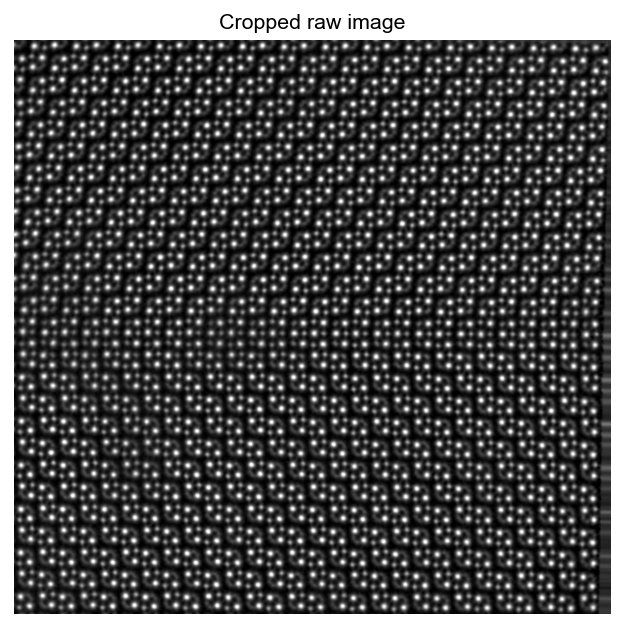

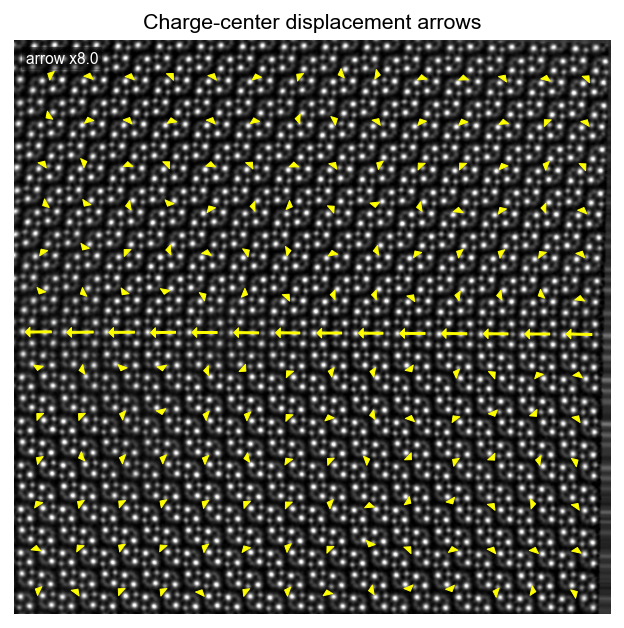

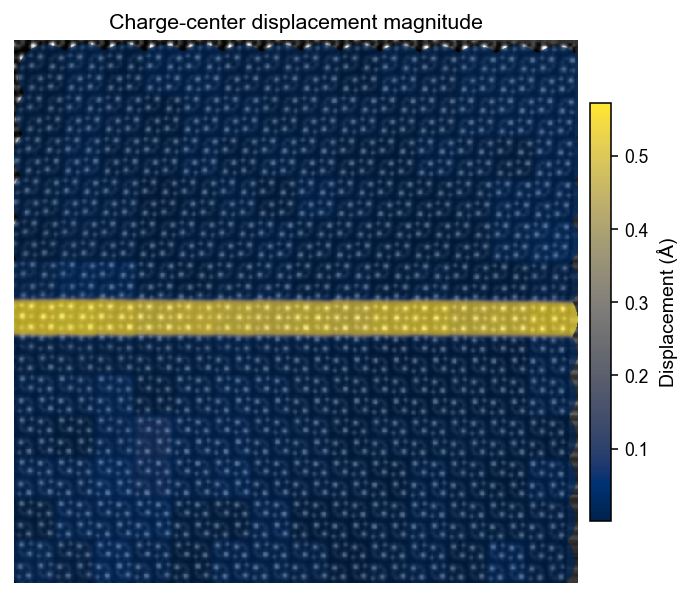

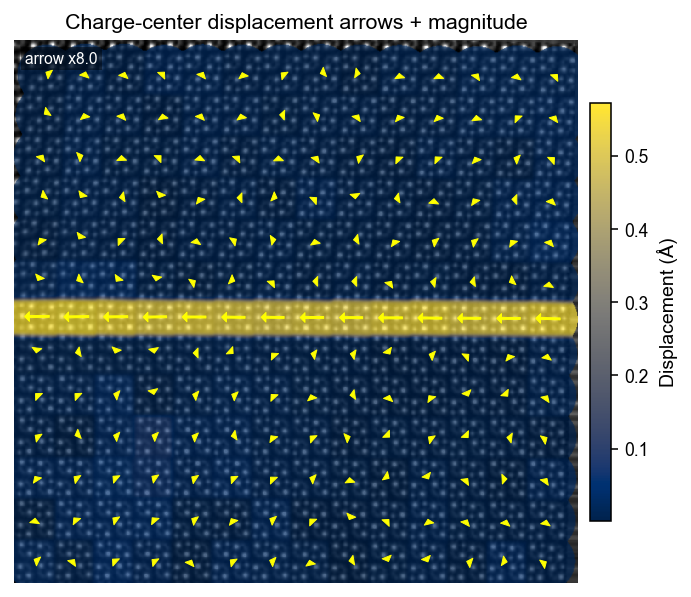

In [10]:
figures = {}
_charge_plot_common = dict(
    image=cropped_background_image,
    measurement_rois=MEASUREMENT_ROIS,
    group_displacement_table=group_displacement_table,
    pixel_to_nm=PIXEL_TO_NM,
    coordinate_space='local',
    style=FIG_STYLE,
    contrast_percentiles=BACKGROUND_CONTRAST_PERCENTILES,
    value_column=VECTOR_VALUE_COLUMN,
    magnitude_cmap=VECTOR_CMAP,
    magnitude_alpha=VECTOR_ALPHA,
    roi_outline_color=ROI_OUTLINE_COLOR,
    roi_outline_linewidth=ROI_OUTLINE_LINEWIDTH,
    roi_outline_alpha=ROI_OUTLINE_ALPHA,
    arrow_color=ARROW_COLOR,
    arrow_edge_color=ARROW_EDGE_COLOR,
    arrow_linewidth=ARROW_LINEWIDTH,
    arrow_mutation_scale=ARROW_MUTATION_SCALE,
    arrow_tail_width=ARROW_TAIL_WIDTH,
    arrow_head_width=ARROW_HEAD_WIDTH,
    arrow_head_length=ARROW_HEAD_LENGTH,
    arrow_alpha=ARROW_ALPHA,
    vector_scale=VECTOR_SCALE,
    vector_auto_target_fraction=VECTOR_AUTO_TARGET_FRACTION,
    vector_auto_max_scale=VECTOR_AUTO_MAX_SCALE,
    show_scalebar=SHOW_SCALEBAR,
    scalebar_length_nm=SCALEBAR_LENGTH_NM,
    scalebar_color=SCALEBAR_COLOR,
    scalebar_linewidth=SCALEBAR_LINEWIDTH,
    scalebar_location=SCALEBAR_LOCATION,
)

_mode_specs = {
    'raw': dict(
        figure_key='cropped_raw_image',
        title='Cropped raw image',
        show_colorbar=False,
        show_roi_outlines=False,
        show_vector_scale_label=False,
    ),
    'arrows': dict(
        figure_key='charge_displacement_arrows',
        title='Charge-center displacement arrows',
        show_colorbar=False,
        show_roi_outlines=SHOW_ROI_OUTLINES,
        show_vector_scale_label=SHOW_VECTOR_SCALE_LABEL,
    ),
    'magnitude': dict(
        figure_key='charge_displacement_magnitude',
        title='Charge-center displacement magnitude',
        show_colorbar=SHOW_VECTOR_COLORBAR,
        show_roi_outlines=SHOW_ROI_OUTLINES,
        show_vector_scale_label=False,
    ),
    'combined': dict(
        figure_key='charge_displacement_arrows_magnitude',
        title='Charge-center displacement arrows + magnitude',
        show_colorbar=SHOW_VECTOR_COLORBAR,
        show_roi_outlines=SHOW_ROI_OUTLINES,
        show_vector_scale_label=SHOW_VECTOR_SCALE_LABEL,
    ),
}

for mode in PLOT_MODES:
    spec = _mode_specs[mode].copy()
    figure_key = spec.pop('figure_key')
    if mode in {'magnitude', 'combined'} and MAGNITUDE_RENDER_MODE in {'feathered_roi', 'smooth_field'}:
        fig, ax = plot_feathered_charge_center_displacement_map(
            mode=mode,
            image=cropped_background_image,
            measurement_rois=MEASUREMENT_ROIS,
            group_displacement_table=group_displacement_table,
            pixel_to_nm=PIXEL_TO_NM,
            coordinate_space='local',
            title=spec['title'],
            contrast_percentiles=BACKGROUND_CONTRAST_PERCENTILES,
            value_column=VECTOR_VALUE_COLUMN,
            magnitude_cmap=VECTOR_CMAP,
            magnitude_alpha=VECTOR_ALPHA,
            show_colorbar=spec['show_colorbar'],
            render_mode=MAGNITUDE_RENDER_MODE,
            roi_expand_px=ROI_EXPAND_PX,
            roi_feather_sigma_px=ROI_FEATHER_SIGMA_PX,
            roi_dilation_px=ROI_DILATION_PX,
            smooth_field_sigma_px=SMOOTH_FIELD_SIGMA_PX,
            smooth_field_min_weight_fraction=SMOOTH_FIELD_MIN_WEIGHT_FRACTION,
            magnitude_clim=MAGNITUDE_CLIM,
            arrow_color=ARROW_COLOR,
            arrow_edge_color=ARROW_EDGE_COLOR,
            arrow_linewidth=ARROW_LINEWIDTH,
            arrow_mutation_scale=ARROW_MUTATION_SCALE,
            arrow_tail_width=ARROW_TAIL_WIDTH,
            arrow_head_width=ARROW_HEAD_WIDTH,
            arrow_head_length=ARROW_HEAD_LENGTH,
            arrow_alpha=ARROW_ALPHA,
            vector_scale=VECTOR_SCALE,
            show_vector_scale_label=spec['show_vector_scale_label'],
        )
    else:
        fig, ax = plot_charge_center_displacement_map(
            mode=mode,
            **spec,
            **_charge_plot_common,
        )
    figures[figure_key] = fig
    display(fig)
    plt.close(fig)

## 5. Optional save

默认不保存。如果需要把这套可视化单独写入文件夹，设置 `SAVE_VISUALIZATION_FIGURES=True`。输出目录和 03 final figures 分开，不覆盖 03 原图。

In [11]:
SAVE_VISUALIZATION_FIGURES = True
VISUALIZATION_OUTPUT_DIR = RESULT_ROOT / '03_group_centroid' / 'figures_visualization_only'
VISUALIZATION_FORMATS = ('png',)
VISUALIZATION_DPI = 300

if SAVE_VISUALIZATION_FIGURES:
    VISUALIZATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved_paths = []
    for name, fig in figures.items():
        for ext in VISUALIZATION_FORMATS:
            path = VISUALIZATION_OUTPUT_DIR / f'{name}.{ext}'
            fig.savefig(path, dpi=VISUALIZATION_DPI, bbox_inches='tight')
            saved_paths.append(path)
    print('saved figures:')
    for path in saved_paths:
        print(path)
else:
    print('SAVE_VISUALIZATION_FIGURES=False; figures were displayed only.')

saved figures:
d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix\03_group_centroid\figures_visualization_only\cropped_raw_image.png
d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix\03_group_centroid\figures_visualization_only\charge_displacement_arrows.png
d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix\03_group_centroid\figures_visualization_only\charge_displacement_magnitude.png
d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix\03_group_centroid\figures_visualization_only\charge_displacement_arrows_magnitude.png
